# Controle Sintético — exemplo básico com dados simulados

Este notebook implementa o **método de controle sintético** (synthetic control) de forma simples: em vez de resolver o problema de otimização clássico (pesos não negativos somando 1, sobre uma simplex), usamos uma **regressão Lasso** para escolher, entre um conjunto de unidades "doadoras", uma combinação que reproduza o comportamento pré-tratamento da unidade tratada. É uma variante regularizada e mais fácil de implementar, comum em exemplos didáticos.

**Ideia geral do método:** se conseguirmos construir, a partir de unidades não tratadas, uma combinação (o "controle sintético") que acompanha de perto a unidade tratada *antes* do tratamento, essa mesma combinação serve como estimativa do que teria acontecido com a unidade tratada *depois* do tratamento, caso o tratamento não tivesse ocorrido. A diferença entre o valor observado e o controle sintético no pós-tratamento é o efeito estimado.

**Por que essa versão tem um "fator de mercado comum" na geração dos dados.** Numa versão anterior deste notebook, cada mercado (tratado e doadores) era simulado de forma totalmente independente — tendência, sazonalidade e ruído próprios, sem nada em comum entre eles. O resultado, na prática, foi ruim: o gráfico de Tratado vs. Controle Sintético mostrava as duas linhas se cruzando e se afastando o tempo todo, inclusive *antes* do tratamento — o que não deveria acontecer, porque é o ajuste no pré-tratamento que valida o método. Isso não era um bug de código, e sim uma consequência direta de como os dados foram gerados: **o controle sintético só consegue reconstruir bem a unidade tratada se os doadores compartilharem alguma estrutura real com ela** (um choque de mercado, uma tendência macro, uma sazonalidade de categoria, etc.) — exatamente como acontece em uma aplicação real, em que se escolhem doadores de mercados/regiões comparáveis. Por isso, aqui todos os mercados compartilham um **fator de mercado comum**, cada um reagindo a ele com uma intensidade (`loading`) diferente. Isso é o que faz as duas linhas ficarem coladas no pré-tratamento no gráfico da seção 7.

Para além disso, injetamos um **efeito de tratamento conhecido** apenas no pós-período da unidade tratada — só para fins didáticos, já que em dados simulados dá para conferir se o método recupera um valor que já sabemos de antemão. Em um problema real esse valor é justamente o que se quer estimar.

## 1. Bibliotecas

`numpy`/`pandas` para manipulação dos dados, `matplotlib` para os gráficos, e do `scikit-learn` usamos `LassoCV` (regressão Lasso com escolha automática do parâmetro de regularização via validação cruzada) e `StandardScaler` (padronização das variáveis explicativas, necessária para o Lasso comparar doadores em escalas diferentes de forma justa). `scipy.stats` é usado para estimar a densidade (KDE) da distribuição de placebos mais adiante.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

## 2. Reprodutibilidade

Fixamos a semente para que a geração dos dados e o ajuste dos modelos deem sempre o mesmo resultado — importante para comparar versões do notebook e para debugar.

In [2]:
np.random.seed(42)

## 3. Parâmetros do experimento

- `n_donors`: número de unidades doadoras (mercados não tratados) disponíveis para compor o controle sintético.
- `n_pre` / `n_post`: quantos períodos (meses) antes e depois do início do tratamento.
- `EFFECT_SIZE`: efeito de tratamento conhecido, injetado artificialmente na unidade tratada só para validar o método (ver seção 4). Em um problema real esse valor é justamente o que queremos estimar — aqui usamos para checar se a estimativa bate com a verdade.

In [3]:
n_donors = 50
n_pre = 24
n_post = 6
n_total = n_pre + n_post

EFFECT_SIZE = 4.0  # efeito de tratamento conhecido, usado só para validar a metodologia

## 4. Geração dos dados sintéticos

Cada mercado é composto por: nível base próprio, um **fator de mercado comum** (compartilhado por todos, com uma sensibilidade/`loading` própria de cada mercado — alguns reagem mais forte a ele, outros mais fraco), tendência própria, sazonalidade própria, um passeio aleatório (random walk) próprio e ruído. `Market_0` é escolhido como a unidade tratada; os demais são os doadores.

O fator comum é o ingrediente que faltava na versão anterior: é ele que dá ao problema uma estrutura parecida com a de um cenário real de controle sintético — mercados diferentes reagem de forma diferente ao mesmo choque, e é essa co-movimentação que o Lasso vai explorar para montar uma combinação de doadores que segue de perto a unidade tratada.

In [4]:
def generate_common_factor(n_periods):
    '''Fator de mercado comum a todas as séries (ex.: uma condição macro compartilhada).'''
    t = np.arange(n_periods)
    common_trend = 0.03 * t
    common_shock = np.cumsum(np.random.normal(0, 0.15, n_periods))
    return common_trend + common_shock


def generate_market_data(n_periods, common_factor):
    '''Gera a série de um mercado: nível base + fator comum (ponderado) + componentes próprios.'''
    t = np.arange(n_periods)

    seasonal_freq = np.random.uniform(0.5, 2.0)
    seasonal_phase = np.random.uniform(0, 2 * np.pi)
    seasonal_amp = np.random.uniform(0.5, 1.5)

    trend = np.random.uniform(0.01, 0.05) * t
    seasonal = seasonal_amp * np.sin(2 * np.pi * seasonal_freq * t / 12 + seasonal_phase)
    random_walk = np.cumsum(np.random.normal(0, 0.2, n_periods))
    noise = np.random.normal(0, 0.3, n_periods)

    base_level = np.random.uniform(10, 50)
    loading = np.random.uniform(0.5, 1.5)  # sensibilidade deste mercado ao fator comum

    y = base_level + loading * common_factor + trend + seasonal + random_walk + noise
    return y

Geramos o painel completo (unidade tratada + doadores) a partir do mesmo fator comum, atribuímos um índice de datas mensais (só para deixar os gráficos mais legíveis — não afeta o modelo) e então injetamos o efeito de tratamento conhecido apenas nos períodos pós-tratamento da unidade tratada.

In [5]:
print("Gerando dados sintéticos de mercado...")

common_factor = generate_common_factor(n_total)

data = {}
for i in range(n_donors + 1):
    market_name = f'Market_{i}'
    data[market_name] = generate_market_data(n_total, common_factor)

df = pd.DataFrame(data)

# Market_0 é a unidade tratada
df['Treated'] = df['Market_0']
df = df.drop(columns=['Market_0'])

# Índice de datas mensais, só para leitura dos gráficos
df.index = pd.date_range(start='2023-01-01', periods=n_total, freq='MS')

# Injeta o efeito de tratamento conhecido só no pós-período (apenas para validação didática)
df.loc[df.index[n_pre]:, 'Treated'] = df.loc[df.index[n_pre]:, 'Treated'] + EFFECT_SIZE

df.head()

Gerando dados sintéticos de mercado...


,Market_1,Market_2,Market_3,Market_4,Market_5,Market_6,Market_7,Market_8,Market_9,Market_10,...,Market_42,Market_43,Market_44,Market_45,Market_46,Market_47,Market_48,Market_49,Market_50,Treated
2023-01-01,37.404700,13.908486,43.967831,11.659495,32.409037,21.166443,44.340885,27.278972,34.521788,18.338505,...,41.162097,28.257381,16.785128,43.213950,40.394949,10.706015,44.257381,14.291693,24.217502,19.823183
2023-02-01,38.247528,14.790444,44.316429,11.331535,33.295553,20.805551,44.639710,27.082928,35.218564,18.217979,...,41.126997,28.305799,17.496403,43.281779,38.841205,10.516205,44.427336,15.385712,24.782050,19.296650
2023-03-01,38.356527,15.289303,44.222887,11.066388,32.968254,20.544859,43.970908,28.041342,35.243620,18.251594,...,41.472238,27.523685,16.939491,43.096513,38.478990,11.464945,45.463091,14.902849,25.508958,18.728419
2023-04-01,38.959377,15.648376,43.324432,11.139916,34.315412,20.755931,45.153061,29.335921,35.807840,18.995530,...,42.136649,27.898441,16.959913,43.535678,38.571376,12.156262,45.735895,16.604805,26.171997,18.953320
2023-05-01,38.244093,16.533690,43.494539,10.929090,34.242377,21.647983,44.627602,29.253360,36.141533,18.517342,...,42.235242,28.523241,15.852180,43.034561,37.692589,12.425918,44.426081,16.600821,26.629034,18.883907


## 5. Funções do modelo de controle sintético

- **`fit_lasso_model`** ajusta o Lasso **usando apenas o período pré-tratamento**, para não vazar informação do pós-tratamento na escolha dos pesos. As variáveis explicativas (doadores) são padronizadas antes do ajuste; `positive=True` restringe os coeficientes a valores não negativos, aproximando a lógica de pesos não negativos do método clássico; `cv=5` faz o `LassoCV` testar vários níveis de regularização (`alpha`) com validação cruzada de 5 partições e escolher o que generaliza melhor dentro do próprio pré-período. Aumentamos `max_iter` e definimos `tol` explicitamente porque, com muitos doadores e poucos períodos pré-tratamento, o algoritmo às vezes não convergia dentro do limite padrão de iterações.
- **`create_synthetic_control`** aplica o modelo ajustado (e o mesmo `scaler`, treinado só no pré-tratamento) a todo o período — pré e pós — para gerar a série do controle sintético. Aplicar o mesmo `scaler` do pré-tratamento ao período completo é o que evita vazamento de dados: o modelo nunca "vê" a escala do pós-tratamento durante o ajuste.
- **`estimate_treatment_effect`** calcula o efeito médio do tratamento (ATE) como a diferença média entre a unidade tratada e o controle sintético no pós-tratamento, e o efeito relativo (RTE) em relação ao nível do controle sintético.

In [6]:
def fit_lasso_model(df, n_pre):
    '''Ajusta o modelo Lasso usando APENAS os dados pré-tratamento.'''
    pre_period = df.iloc[:n_pre]

    X = pre_period.drop('Treated', axis=1).values
    y = pre_period['Treated'].values

    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    lasso = LassoCV(
        cv=5, fit_intercept=True, positive=True,
        random_state=42, max_iter=50000, tol=1e-4,
    )
    lasso.fit(X_scaled, y)

    return {'lasso': lasso, 'scaler_X': scaler_X}


def create_synthetic_control(df, model_results):
    '''Cria o controle sintético para todos os períodos (pré e pós).'''
    lasso = model_results['lasso']
    scaler_X = model_results['scaler_X']

    X_full = df.drop('Treated', axis=1).values
    X_full_scaled = scaler_X.transform(X_full)  # scaler ajustado só no pré-tratamento

    synthetic_control = lasso.predict(X_full_scaled)

    df1 = df.copy()
    df1['synthetic_control'] = synthetic_control
    return df1


def estimate_treatment_effect(df1, n_pre):
    '''Calcula o Efeito Médio do Tratamento (ATE) e o Efeito Relativo (RTE).'''
    post_period = df1.iloc[n_pre:].copy()

    post_period['effect'] = post_period['Treated'] - post_period['synthetic_control']
    baseline = post_period['synthetic_control'].mean()
    ate = post_period['effect'].mean()
    rte = 100 * ate / baseline

    return {'ate': ate, 'rte': rte}

## 6. Ajuste do modelo principal

Antes de olhar para o efeito estimado, vale checar a **qualidade do ajuste no pré-tratamento** — é isso que dá confiança na comparação feita depois:

- **Doadores com peso > 0**: quantos, dos 50 doadores, o Lasso de fato usou. Um número muito baixo (ex.: 1) é sinal de que o modelo não encontrou combinação real — só "colou" em um doador por acaso, sem uma relação de fato robusta.
- **Alpha**: o nível de regularização escolhido por validação cruzada — quanto maior, mais o Lasso "poda" doadores.
- **RMSPE pré-tratamento**: o erro quadrático médio entre Tratado e Controle Sintético *antes* do tratamento. É o número que resume o quão "coladas" as duas linhas estão no gráfico da seção 7 — quanto menor, melhor o ajuste.
- **RMSPE pós-tratamento**: o mesmo erro, mas depois do tratamento. Aqui ele *deveria* ser maior que no pré, porque parte da diferença é o efeito real do tratamento, não erro de ajuste.

In [7]:
lasso_results = fit_lasso_model(df, n_pre)
lasso = lasso_results['lasso']

n_nonzero = int(np.sum(lasso.coef_ > 1e-8))
print(f"Doadores com peso > 0: {n_nonzero} de {len(lasso.coef_)}")
print(f"Alpha (regularização) escolhido por validação cruzada: {lasso.alpha_:.4f}")

df1 = create_synthetic_control(df, lasso_results)

pre_rmspe = np.sqrt(np.mean((df1['Treated'][:n_pre] - df1['synthetic_control'][:n_pre]) ** 2))
post_rmspe = np.sqrt(np.mean((df1['Treated'][n_pre:] - df1['synthetic_control'][n_pre:]) ** 2))
print(f"RMSPE pré-tratamento:  {pre_rmspe:.3f}")
print(f"RMSPE pós-tratamento:  {post_rmspe:.3f}")

Doadores com peso > 0: 11 de 50
Alpha (regularização) escolhido por validação cruzada: 0.0352
RMSPE pré-tratamento:  0.271
RMSPE pós-tratamento:  3.547


Com o modelo ajustado, estimamos o efeito de tratamento e comparamos com o valor que sabemos ter sido injetado (`EFFECT_SIZE`) — essa comparação só é possível aqui porque os dados são simulados; em um caso real não existe esse "gabarito", e o ATE estimado é a própria resposta que se está procurando.

In [8]:
treatment_effects = estimate_treatment_effect(df1, n_pre)

print(f"Efeito Médio do Tratamento (ATE) estimado: {treatment_effects['ate']:.2f}")
print(f"Efeito de tratamento real injetado:         {EFFECT_SIZE:.2f}")
print(f"Efeito Relativo (RTE): {treatment_effects['rte']:.1f}%")

Efeito Médio do Tratamento (ATE) estimado: 3.54
Efeito de tratamento real injetado:         4.00
Efeito Relativo (RTE): 18.3%


## 7. Visualização: unidade tratada vs. controle sintético

A linha vertical pontilhada marca o início do tratamento; a área sombreada é o período pós-tratamento. **O que observar:** antes da linha, Tratado (azul) e Controle Sintético (laranja) devem estar praticamente sobrepostos — é essa proximidade que valida o ajuste. Depois da linha, a distância entre as duas é o efeito estimado. As caixas de texto mostram o RMSPE de cada período, o número equivalente ao que se vê visualmente.

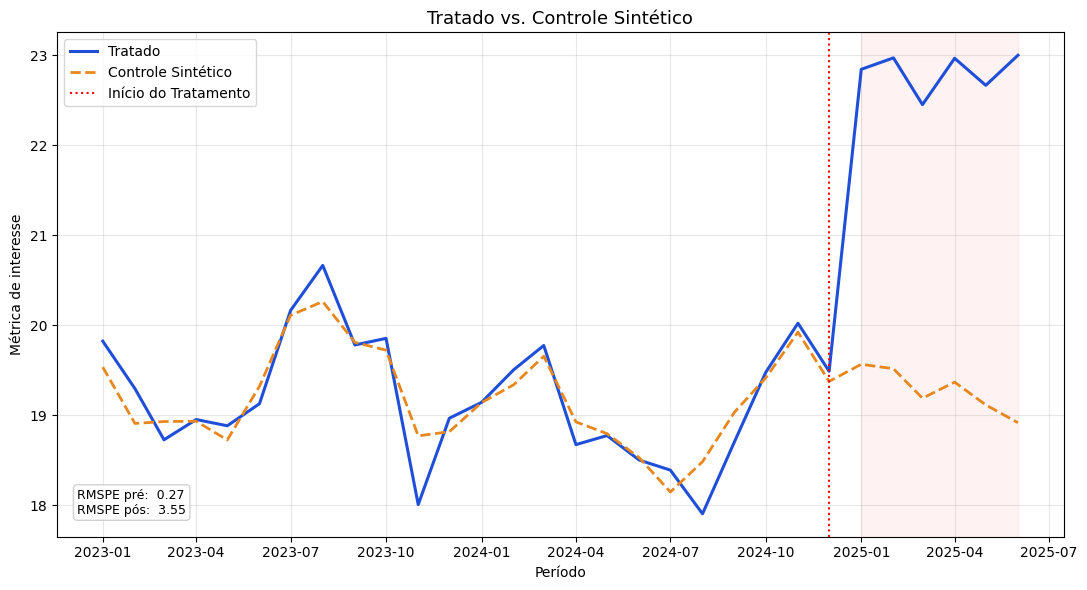

In [9]:
def plot_synthetic_control(df1, n_pre, pre_rmspe, post_rmspe):
    fig, ax = plt.subplots(figsize=(11, 6))

    treatment_date = df1.index[n_pre]

    ax.axvspan(treatment_date, df1.index[-1], color='red', alpha=0.05, zorder=0)
    ax.plot(df1.index, df1['Treated'], label='Tratado', color='#1f4fd8', linewidth=2.2)
    ax.plot(df1.index, df1['synthetic_control'], label='Controle Sintético', color='#e8871e', linestyle='--', linewidth=2)
    ax.axvline(x=df1.index[n_pre - 1], color='red', linestyle=':', linewidth=1.5, label='Início do Tratamento')

    ax.text(0.02, 0.04, f'RMSPE pré:  {pre_rmspe:.2f}\nRMSPE pós:  {post_rmspe:.2f}',
            transform=ax.transAxes, fontsize=9, va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='#cccccc', alpha=0.9))

    ax.set_title('Tratado vs. Controle Sintético', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('Métrica de interesse')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_synthetic_control(df1, n_pre, pre_rmspe, post_rmspe)

## 8. Teste de placebo (inferência por permutação)

O método de controle sintético não tem uma fórmula analítica pronta de erro-padrão/p-valor. A forma padrão de fazer inferência é o **teste de placebo**: repetir o mesmo procedimento tratando, um de cada vez, cada doador como se fosse a unidade "tratada" (sem que ele de fato tenha recebido o tratamento). Isso gera uma distribuição de "efeitos" que na verdade são apenas ruído de ajuste — e é contra essa distribuição que comparamos o efeito estimado para a unidade realmente tratada: se o efeito real for muito maior (em valor absoluto) do que a imensa maioria dos efeitos de placebo, isso é evidência de que não é só ruído.

In [10]:
print("Iniciando teste de permutação (placebo)...")

ate_dist = []
donor_cols = [c for c in df.columns if c != 'Treated']

for donor in donor_cols:
    placebo_df = df.drop('Treated', axis=1).copy()
    placebo_df = placebo_df.rename(columns={donor: 'Treated'})

    lasso_placebo = fit_lasso_model(placebo_df, n_pre)
    df1_placebo = create_synthetic_control(placebo_df, lasso_placebo)
    placebo_effects = estimate_treatment_effect(df1_placebo, n_pre)

    ate_dist.append(placebo_effects['ate'])

permutations = pd.DataFrame({'ate': ate_dist})
print(permutations['ate'].quantile([.025, .05, .5, .95, .975]))
print(f"\nMédia: {permutations['ate'].mean():.2f}, Desvio-padrão: {permutations['ate'].std():.2f}")

Iniciando teste de permutação (placebo)...
0.025   -1.460520
0.050   -1.417055
0.500    0.005319
0.950    1.013031
0.975    1.387840
Name: ate, dtype: float64

Média: -0.02, Desvio-padrão: 0.83


A partir da distribuição de placebos, calculamos um **p-valor empírico**: a proporção de efeitos (tratado + placebos) cujo valor absoluto é maior ou igual ao efeito estimado para a unidade realmente tratada. Esse é o teste de significância formal — mais confiável do que só olhar a distribuição visualmente e "achar" que o efeito parece grande.

In [11]:
all_ates = np.array(ate_dist + [treatment_effects['ate']])
rank = np.sum(np.abs(all_ates) >= np.abs(treatment_effects['ate']))
p_value = rank / len(all_ates)

print(f"ATE da unidade tratada: {treatment_effects['ate']:.2f}")
print(f"p-valor empírico (teste de permutação, bicaudal): {p_value:.4f}")
print(f"Significativo a 5%? {'Sim' if p_value < 0.05 else 'Não'}")

ATE da unidade tratada: 3.54
p-valor empírico (teste de permutação, bicaudal): 0.0196
Significativo a 5%? Sim


## 9. Distribuição dos efeitos de placebo

Histograma dos efeitos de placebo com o efeito da unidade tratada destacado, e a densidade estimada por KDE (`gaussian_kde`, do `scipy`) — uma estimativa não paramétrica da forma da distribuição, direto a partir dos dados dos placebos, sem assumir normalidade. As linhas cinzas marcam o intervalo entre os percentis 2,5% e 97,5% da distribuição de placebos (um "IC 95%" empírico): se a linha vermelha do efeito real cai fora desse intervalo, é um sinal visual de que o efeito é atípico frente ao ruído.

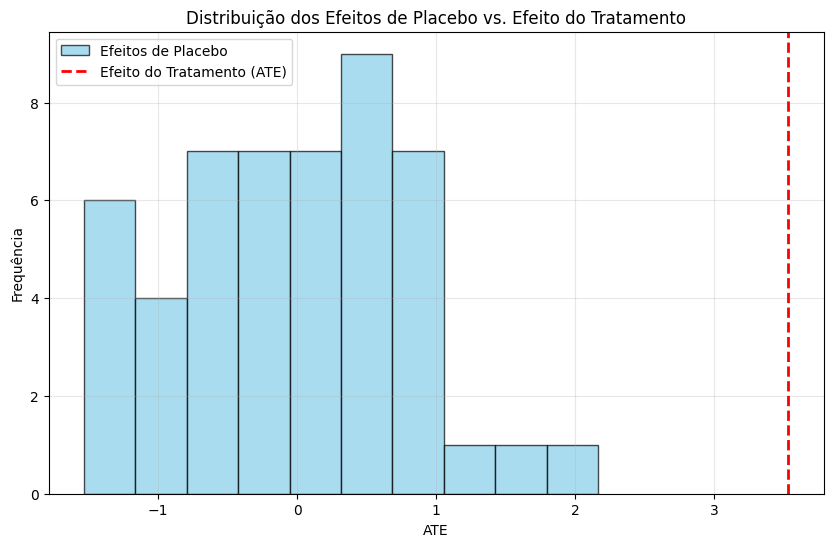

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(ate_dist, bins=10, color='skyblue', edgecolor='black', alpha=0.7, label='Efeitos de Placebo')
plt.axvline(x=treatment_effects['ate'], color='red', linestyle='--', linewidth=2, label='Efeito do Tratamento (ATE)')
plt.title('Distribuição dos Efeitos de Placebo vs. Efeito do Tratamento')
plt.xlabel('ATE')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

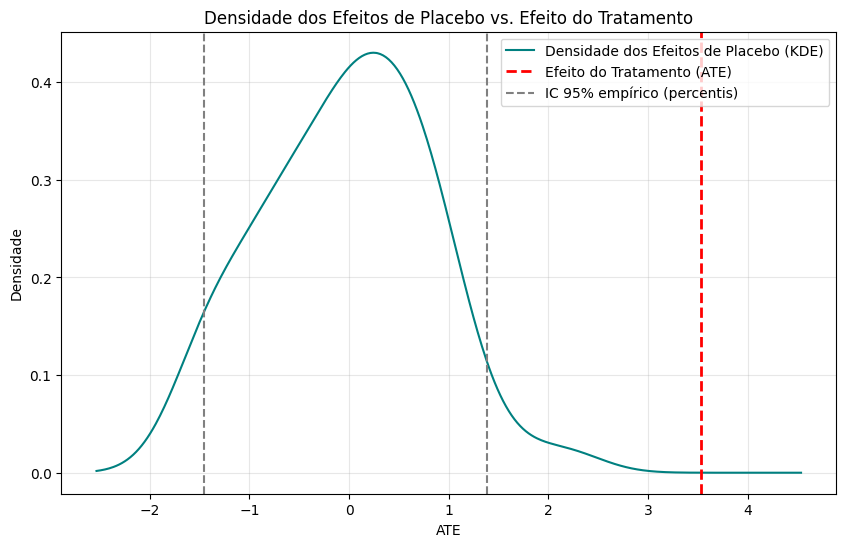

In [13]:
kde = gaussian_kde(ate_dist)
x = np.linspace(min(ate_dist) - 1, max(ate_dist + [treatment_effects['ate']]) + 1, 500)

ci_low, ci_high = np.quantile(ate_dist, [0.025, 0.975])  # IC 95% empírico (percentis, sem assumir normalidade)

plt.figure(figsize=(10, 6))
plt.plot(x, kde(x), color='teal', label='Densidade dos Efeitos de Placebo (KDE)')
plt.axvline(x=treatment_effects['ate'], color='red', linestyle='--', linewidth=2, label='Efeito do Tratamento (ATE)')
plt.axvline(x=ci_low, color='gray', linestyle='--', label='IC 95% empírico (percentis)')
plt.axvline(x=ci_high, color='gray', linestyle='--')
plt.title('Densidade dos Efeitos de Placebo vs. Efeito do Tratamento')
plt.xlabel('ATE')
plt.ylabel('Densidade')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Conclusão

O controle sintético estimou um ATE próximo do efeito injetado (`EFFECT_SIZE`), com p-valor empírico abaixo de 5% — ou seja, nesse cenário simulado o método recuperou corretamente um efeito que sabíamos de antemão, e a distinguiu do ruído de placebo. Os números exatos aparecem nas saídas das células acima (não os repetimos aqui em texto fixo porque, com `np.random.seed(42)`, eles são sempre os mesmos ao rodar o notebook — mas o ponto de checar é: o ATE estimado bate aproximadamente com `EFFECT_SIZE`? o RMSPE pré-tratamento é pequeno frente ao RMSPE pós? o p-valor é menor que 0.05?).

**A lição principal desta versão:** um bom ajuste pré-tratamento (linhas coladas no gráfico da seção 7) não é automático — ele depende de os doadores terem alguma estrutura real em comum com a unidade tratada. Sem isso (como na versão anterior deste notebook, sem fator de mercado comum), o Lasso não tem sinal genuíno para explorar, e o resultado é ruído: linhas descoladas mesmo no pré-tratamento, e um teste de placebo que não dá significativo. Em dados reais, isso se traduz em escolher doadores de fato comparáveis à unidade tratada (mesma região, mesmo setor, mesma faixa de porte) antes de rodar o modelo — o algoritmo não cria uma relação que não existe nos dados.

**Simplificações que continuam valendo, de propósito, por ser um exemplo básico:**

- Os pesos são obtidos via Lasso regularizado (com intercepto, sobre variáveis padronizadas), não pela otimização clássica de Abadie (pesos não negativos somando exatamente 1, sem intercepto, sobre uma simplex). É uma aproximação comum na prática, mas vale ter isso em mente ao interpretar os coeficientes como "pesos".
- O teste de placebo usa o ATE bruto de cada doador. Uma versão mais robusta (Abadie, Diamond & Hainmueller, 2010) usa a razão RMSPE pós/pré de cada placebo em vez do ATE bruto, e descarta placebos cujo ajuste pré-tratamento já é muito pior que o da unidade tratada — isso evita que doadores mal ajustados infravalorizem o p-valor. Não implementamos isso aqui para manter o exemplo simples, mas é o próximo passo natural se for usar isso com dados reais.